In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

with zipfile.ZipFile('/content/drive/MyDrive/열화상.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/열화상')

print("압축 해제 완료")
print(os.listdir('/content/drive/MyDrive/열화상'))

압축 해제 완료
['정상 열화상', '불량 열화상']


In [6]:
import glob

In [8]:
base_dir = "/content/drive/MyDrive/열화상"
class_paths = {
    0: os.path.join(base_dir, "정상 열화상", "정상 0단계"),
    1: os.path.join(base_dir, "정상 열화상", "정상 1단계"),
    2: os.path.join(base_dir, "정상 열화상", "정상 2단계"),
    3: os.path.join(base_dir, "불량 열화상", "불량 3단계"),
    4: os.path.join(base_dir, "불량 열화상", "불량 4단계")
}

train_paths, train_labels = [], []
val_paths, val_labels = [], []

for label, path in class_paths.items():
    images = sorted(glob.glob(os.path.join(path, "*.jpg")) + glob.glob(os.path.join(path, "*.png")))
    split_idx = int(len(images) * 0.7)

    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    train_paths.extend(train_imgs)
    train_labels.extend([label] * len(train_imgs))
    val_paths.extend(val_imgs)
    val_labels.extend([label] * len(val_imgs))

    print(f"[{label}단계] 전체 {len(images)}장 -> Train {len(train_imgs)} / Val {len(val_imgs)}")

print(f"\n전체 Train: {len(train_paths)}장 / Val: {len(val_paths)}장")

[0단계] 전체 208장 -> Train 145 / Val 63
[1단계] 전체 201장 -> Train 140 / Val 61
[2단계] 전체 204장 -> Train 142 / Val 62
[3단계] 전체 221장 -> Train 154 / Val 67
[4단계] 전체 202장 -> Train 141 / Val 61

전체 Train: 722장 / Val: 314장


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class PeltierDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32

train_dataset = PeltierDataset(train_paths, train_labels, transform=transform)
val_dataset = PeltierDataset(val_paths, val_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train 배치 수: {len(train_loader)}, Val 배치 수: {len(val_loader)}")

Train 배치 수: 23, Val 배치 수: 10


In [11]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 장치: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%  ||  "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("학습 완료")

사용 중인 장치: cpu
Epoch [01/10] Train Loss: 0.2081 | Train Acc: 94.88%  ||  Val Loss: 0.0709 | Val Acc: 97.77%
Epoch [02/10] Train Loss: 0.0030 | Train Acc: 100.00%  ||  Val Loss: 0.1417 | Val Acc: 93.95%
Epoch [03/10] Train Loss: 0.0021 | Train Acc: 100.00%  ||  Val Loss: 0.1423 | Val Acc: 93.63%
Epoch [04/10] Train Loss: 0.0016 | Train Acc: 100.00%  ||  Val Loss: 0.1125 | Val Acc: 94.90%
Epoch [05/10] Train Loss: 0.0011 | Train Acc: 100.00%  ||  Val Loss: 0.1198 | Val Acc: 93.95%
Epoch [06/10] Train Loss: 0.0011 | Train Acc: 100.00%  ||  Val Loss: 0.1204 | Val Acc: 93.95%
Epoch [07/10] Train Loss: 0.0010 | Train Acc: 100.00%  ||  Val Loss: 0.1423 | Val Acc: 93.95%
Epoch [08/10] Train Loss: 0.0007 | Train Acc: 100.00%  ||  Val Loss: 0.1105 | Val Acc: 94.27%
Epoch [09/10] Train Loss: 0.0004 | Train Acc: 100.00%  ||  Val Loss: 0.1064 | Val Acc: 93.95%
Epoch [10/10] Train Loss: 0.0006 | Train Acc: 100.00%  ||  Val Loss: 0.1222 | Val Acc: 93.95%
학습 완료


              precision    recall  f1-score   support

  정상 (0~2단계)       1.00      1.00      1.00       186
  불량 (3~4단계)       1.00      1.00      1.00       128

    accuracy                           1.00       314
   macro avg       1.00      1.00      1.00       314
weighted avg       1.00      1.00      1.00       314



/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()

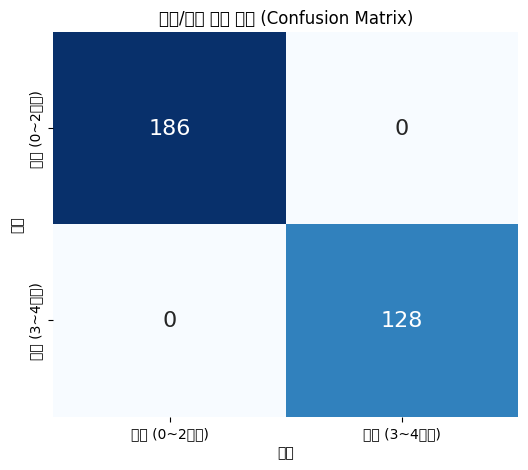

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

def map_to_binary(label_list):
    return [0 if label in [0, 1, 2] else 1 for label in label_list]

binary_labels = map_to_binary(all_labels)
binary_preds = map_to_binary(all_preds)

cm = confusion_matrix(binary_labels, binary_preds)
class_names = ['정상 (0~2단계)', '불량 (3~4단계)']

print(classification_report(binary_labels, binary_preds, target_names=class_names))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16})
plt.title('정상/불량 분류 결과 (Confusion Matrix)')
plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [13]:
import zipfile
import os

with zipfile.ZipFile('/content/drive/MyDrive/사진.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/사진')

print("압축 해제 완료")
print(os.listdir('/content/drive/MyDrive/사진'))

압축 해제 완료
['정상 사진', '불량 사진']


In [15]:
import glob

base_dir = "/content/drive/MyDrive/사진"
class_paths = {
    0: os.path.join(base_dir, "정상 사진"),
    1: os.path.join(base_dir, "불량 사진")
}

train_paths, train_labels = [], []
val_paths, val_labels = [], []

for label, path in class_paths.items():
    images = sorted(glob.glob(os.path.join(path, "*.jpg")) + glob.glob(os.path.join(path, "*.png")))
    split_idx = int(len(images) * 0.7)

    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    train_paths.extend(train_imgs)
    train_labels.extend([label] * len(train_imgs))
    val_paths.extend(val_imgs)
    val_labels.extend([label] * len(val_imgs))

    print(f"[{label}] 전체 {len(images)}장 -> Train {len(train_imgs)} / Val {len(val_imgs)}")

print(f"\n전체 Train: {len(train_paths)}장 / Val: {len(val_paths)}장")

[0] 전체 264장 -> Train 184 / Val 80
[1] 전체 261장 -> Train 182 / Val 79

전체 Train: 366장 / Val: 159장


In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class LeakDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32

train_dataset = LeakDataset(train_paths, train_labels, transform=transform)
val_dataset = LeakDataset(val_paths, val_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train 배치 수: {len(train_loader)}, Val 배치 수: {len(val_loader)}")

Train 배치 수: 12, Val 배치 수: 5


In [17]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 장치: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)   # 정상/불량 2클래스
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%  ||  "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("학습 완료")

사용 중인 장치: cpu
Epoch [01/10] Train Loss: 0.0789 | Train Acc: 94.54%  ||  Val Loss: 0.0021 | Val Acc: 100.00%
Epoch [02/10] Train Loss: 0.0007 | Train Acc: 100.00%  ||  Val Loss: 0.0003 | Val Acc: 100.00%
Epoch [03/10] Train Loss: 0.0004 | Train Acc: 100.00%  ||  Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [04/10] Train Loss: 0.0002 | Train Acc: 100.00%  ||  Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [05/10] Train Loss: 0.0002 | Train Acc: 100.00%  ||  Val Loss: 0.0002 | Val Acc: 100.00%
Epoch [06/10] Train Loss: 0.0001 | Train Acc: 100.00%  ||  Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [07/10] Train Loss: 0.0001 | Train Acc: 100.00%  ||  Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [08/10] Train Loss: 0.0001 | Train Acc: 100.00%  ||  Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [09/10] Train Loss: 0.0001 | Train Acc: 100.00%  ||  Val Loss: 0.0001 | Val Acc: 100.00%
Epoch [10/10] Train Loss: 0.0002 | Train Acc: 100.00%  ||  Val Loss: 0.0001 | Val Acc: 100.00%
학습 완료


              precision    recall  f1-score   support

          정상       1.00      1.00      1.00        80
          불량       1.00      1.00      1.00        79

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159



/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing fr

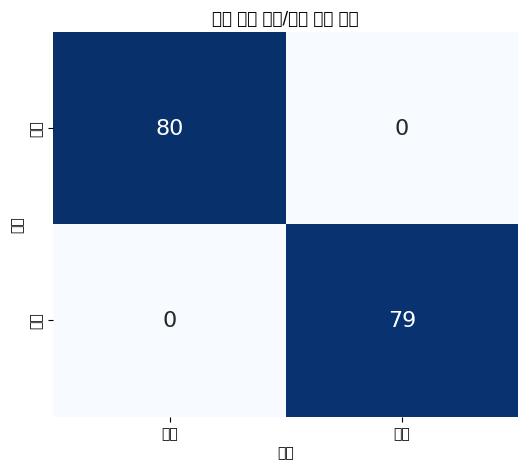

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = ['정상', '불량']

print(classification_report(all_labels, all_preds, target_names=class_names))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 16})
plt.title('누수 감지 정상/불량 분류 결과')
plt.xlabel('예측')
plt.ylabel('실제')
plt.show()